In [1]:
import PyMoosh as pm
import numpy as  np
import matplotlib.pyplot as plt
%matplotlib widget
#plt.rcParams['figure.dpi'] = 150
from phc_codes.phc_utils import refractive_index, plot_layers


nPVA = 1.4858 + 0.0001j
nPDMS = lambda x : (1+1.0093/(1-13185.0/x**2))**.5
nglyc = 1.4722 # glycerol

In [2]:
ni = 1.0 #refractive_index("Water")
nf = refractive_index("Quartz_expt")
nh = refractive_index("TiO2_expt")  # 2.41 + 0.0024j    #
nl = refractive_index("SiO2_expt")  # 1.46 + 0.0010j  #
nm = refractive_index("Ag50nm")
nfinal = nPVA

# Two materials of different optical index. The larger the difference in index, the more efficient the mirror will be
tl = 100
th = 62
tl_mod = tl #* 2.9#+ 90
th_mod = 0 #th *.36 #* 2.9#+ 90
tfinal = 1600
tm = 30
tsub = 500
tsup = 500

Theta_i = 0   / 180 * np.pi

materials = [
        lambda x : ni**2,    #0
        lambda x : nl(x)**2,    #1
        lambda x : nh(x)**2,    #2
        lambda x : nf(x)**2,    #3
        lambda x : nfinal**2,    #4
        lambda x : nm(x)**2      #5
    ]

lay_pairs = 8

stack = [0, 5, 4] + [1, 2] * lay_pairs + [3]
thicknesses = [tsup, tm, tfinal] + [tl, th] * (lay_pairs-1) + [tl_mod, th] + [tsub]

total_thickness = sum(thicknesses)
prism_coupler = pm.Structure(materials,stack,thicknesses)

print(thicknesses, stack)

List of materials:
Custom dispersive material. Epsilon= <lambda> (wavelength in nm)
Custom dispersive material. Epsilon= <lambda> (wavelength in nm)
Custom dispersive material. Epsilon= <lambda> (wavelength in nm)
Custom dispersive material. Epsilon= <lambda> (wavelength in nm)
Custom dispersive material. Epsilon= <lambda> (wavelength in nm)
Custom dispersive material. Epsilon= <lambda> (wavelength in nm)
[500, 30, 1600, 100, 62, 100, 62, 100, 62, 100, 62, 100, 62, 100, 62, 100, 62, 100, 62, 500] [0, 5, 4, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 3]


In [3]:
n_wls = 5000
tm_i= 0
tm_f = 100
n_t = 500

wl_i = 450
wl_f = 750
polarization = 0 # TE=0, TM=1


In [4]:
# Generating data arrays -----------------------------------------------
tm_s = np.linspace(tm_i, tm_f, n_t)  # thickness of metal layers
Reflectance = np.zeros((n_wls, n_t))

for k, t_m in enumerate(tm_s):
    prism_coupler.thickness[1] = t_m # modify layer thickness
    wls, r, t, R, T = pm.spectrum(prism_coupler, Theta_i, polarization, wl_i, wl_f, n_wls)
    Reflectance[:, k] = R.T

## plot dispersion

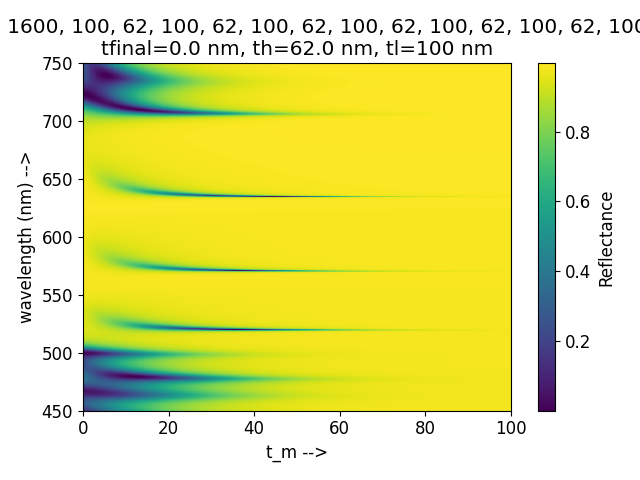

In [5]:
plt.figure(3)
plt.clf()
plt.rcParams.update({'font.size': 12})
Th, Lmda = np.meshgrid(tm_s, wls)
plt.pcolormesh(Th, Lmda, Reflectance, lw=1,) # cmap="gist_gray")
plt.colorbar(label="Reflectance")
plt.xlabel(r"t_m -->")
plt.ylabel(r"wavelength (nm) -->")
plt.title(f"{thicknesses}\ntfinal={th_mod:.1f} nm, th={th:.1f} nm, tl={tl} nm")
plt.tight_layout()
plt.show()

## Reflectivity at specific thickness of the tuning layer

In [6]:
plot_t = [0, 40, 50, 70, 100]


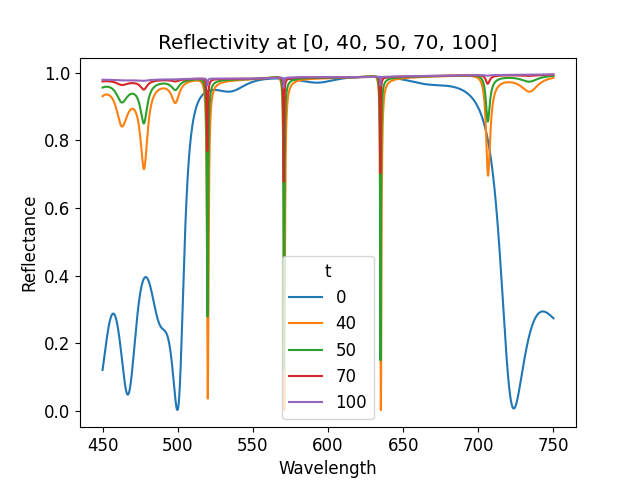

In [7]:
plt.figure(5)
plt.clf()

for t in plot_t:
    prism_coupler.thickness[1] = t # modify layer thickness
    _, r, t, R, T = pm.spectrum(prism_coupler, Theta_i, polarization, wl_i, wl_f, n_wls)
    plt.plot(wls, R)

plt.legend(plot_t, title="t")
plt.xlabel("Wavelength")
plt.ylabel("Reflectance")
plt.title(f"Reflectivity at {plot_t}")
plt.show()

## E_field plot

In [8]:
wl = 570.9
prism_coupler.thickness[1] = 40 # modify layer thickness

Pixels horizontally: 2854
Incidence in degrees: 0.0
E//, TE, s polarization
Pixels vertically: 1968


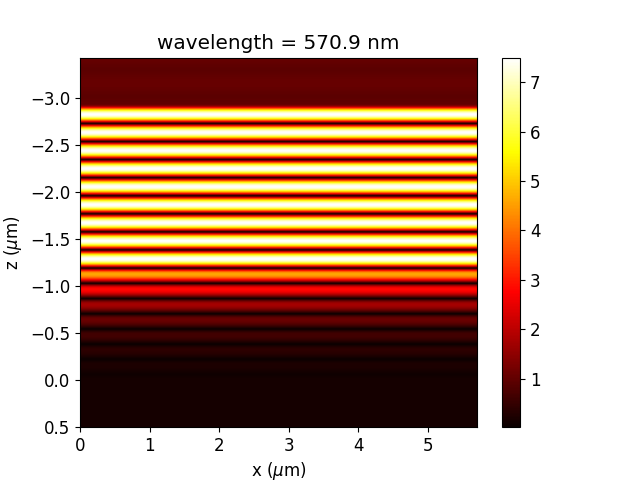

In [9]:
domain = pm.Window(10 * wl, 0.3, 2.0, 2.0)
beam = pm.Beam(wl, Theta_i , polarization, 10 * wl)

E = pm.field(prism_coupler, beam, domain)
norm_E = abs(E)
#norm_E /= max(norm_E[:, 100])
plt.figure(7)
plt.clf()
ax = plt.axes()
plt.imshow(
     norm_E[::-1, :],
    cmap="hot",
    extent=[0, domain.width/1000, +0.5 - total_thickness/1000,  0.5],
    aspect="auto",
)
plt.colorbar()
plt.xlabel(r"x ($\mu$m)")
plt.ylabel(r"z ($\mu$m)")
plt.title(f"wavelength = {wl} nm")
ax.invert_yaxis()
plt.show()



## line plot  of the energy density

TypeError: plot_layers() missing 1 required positional argument: 'xlim'

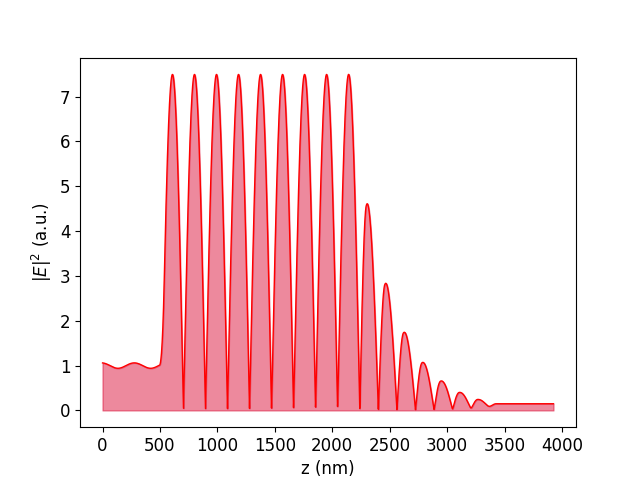

In [10]:
plt.figure(8)
plt.clf()
ax = plt.axes()
lineplot_x = 1050
#plt.plot(abs(np.sum(E, axis=1)))
xx, yy = np.linspace(0, total_thickness, len(norm_E[:, lineplot_x])), norm_E[:, lineplot_x]
plt.plot(xx, yy, "r", lw=1)
plt.fill_between(xx, yy, alpha=0.5, color='crimson')
plt.xlabel(r"z (nm)")
plt.ylabel("$|E|^2$ (a.u.)")


'''ax.set_xticks(
    np.linspace(0, domain.ny * domain.py, 8),
    ["%.1f" % a for a in np.linspace(tsup/1000- np.sum(prism_coupler.thickness)/1000, tsup/1000, 8)]
)'''
plot_layers(prism_coupler, ylim=max(yy))
plt.title(f"wavelength = {wl} nm")
#plt.legend(["Integrated intensity", f"intensity at x={lineplot_x*30}"])
plt.tight_layout()
plt.show()